In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ecommerce_sales.csv')

In [3]:
df

,OrderID,Product,Category,Quantity,Price,Revenue,Month
0,5001,Laptop,Electronics,6,2846,17076,Mar
1,5002,Phone,Electronics,6,27367,164202,Mar
2,5003,Watch,Accessories,5,31688,158440,Feb
3,5004,Headphone,Accessories,8,34941,279528,Apr
4,5005,Laptop,Accessories,3,45814,137442,Apr
...,...,...,...,...,...,...,...
95,5096,Phone,Electronics,1,5591,5591,Feb
96,5097,Watch,Accessories,1,36270,36270,Mar
97,5098,Watch,Electronics,3,31957,95871,Mar
98,5099,Watch,Electronics,7,9567,66969,Apr


In [4]:
df.shape

(100, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   OrderID   100 non-null    int64
 1   Product   100 non-null    str  
 2   Category  100 non-null    str  
 3   Quantity  100 non-null    int64
 4   Price     100 non-null    int64
 5   Revenue   100 non-null    int64
 6   Month     100 non-null    str  
dtypes: int64(4), str(3)
memory usage: 5.6 KB


In [6]:
df.sample(3)

,OrderID,Product,Category,Quantity,Price,Revenue,Month
85,5086,Headphone,Electronics,2,24027,48054,Jan
20,5021,Laptop,Electronics,1,47865,47865,Apr
77,5078,Phone,Accessories,5,19212,96060,Jan


# NUMPY

In [7]:
print("Sample random records:\n",df.sample(3))

Sample random records:
     OrderID Product     Category  Quantity  Price  Revenue Month
18     5019   Watch  Accessories         1  38137    38137   Feb
77     5078   Phone  Accessories         5  19212    96060   Jan
35     5036   Watch  Accessories         9   3331    29979   Feb


In [8]:
np.sum(df['Revenue'])

np.int64(11569632)

In [9]:
np.average(df['Revenue'])

np.float64(115696.32)

In [10]:
np.max(df['Price'])

np.int64(49727)

# PANDAS

In [11]:
df.sample(3)

,OrderID,Product,Category,Quantity,Price,Revenue,Month
17,5018,Watch,Electronics,7,13489,94423,Mar
68,5069,Laptop,Electronics,8,39441,315528,Mar
31,5032,Tablet,Electronics,9,35036,315324,Apr


In [12]:
df[['Product','Price']].sort_values(by = 'Price' ,ascending=False).head(3)

,Product,Price
26,Phone,49727
46,Tablet,48092
20,Laptop,47865


In [13]:
# df.groupby('Category').sum('Revenue')
df.groupby('Category')['Revenue'].sum()


Category
Accessories    5333392
Electronics    6236240
Name: Revenue, dtype: int64

In [28]:
df.groupby('Category').agg({'Revenue': 'sum'})
# https://chatgpt.com/s/t_6a1203c78f288191a7ab3c9dc19400c1


,Revenue
Category,
Accessories,5333392
Electronics,6236240


In [27]:
df.groupby('Category').agg({
    'Revenue': 'sum',
    'Price': 'mean'
})

,Revenue,Price
Category,,
Accessories,5333392,22065.450980
Electronics,6236240,23696.142857


In [15]:
df.groupby('Category').sum()


,OrderID,Product,Quantity,Price,Revenue,Month
Category,,,,,,
Accessories,257664,WatchHeadphoneLaptopHeadphoneLaptopTabletWatch...,246,1125338,5333392,FebAprAprAprJanJanJanFebJanFebMarMarJanFebFebA...
Electronics,247386,LaptopPhoneLaptopTabletLaptopTabletPhoneWatchT...,258,1161111,6236240,MarMarMarMarAprJanFebMarFebFebMarAprAprMarFebJ...


In [16]:
df.groupby('Month')['Revenue'].sum()

Month
Apr    3398585
Feb    1985026
Jan    3597840
Mar    2588181
Name: Revenue, dtype: int64

In [30]:
order = ["Jan", "Feb", "Mar", "Apr"]
df['Month'] = pd.Categorical(df['Month'], categories=order, ordered=True)

df.groupby('Month')['Revenue'].sum().sort_index()

#1 https://chatgpt.com/s/t_6a120407cc288191a4b93e4e53e30d9f

#2 https://chatgpt.com/s/t_6a12057a7b888191b295122e5c2eab53


Month
Jan    3597840
Feb    1985026
Mar    2588181
Apr    3398585
Name: Revenue, dtype: int64

In [ ]:
# df['OrderID',df['Revenue']>100000]
df[df['Revenue'] > 100000]['OrderID'].head()

df[[df['Revenue']] > 100000]['OrderID'].head()

# df.loc(df['Revenue']>100000,[''])


1    5002
2    5003
3    5004
4    5005
7    5008
Name: OrderID, dtype: int64

In [19]:
df.loc[df['Revenue'] > 100000, ['OrderID', 'Revenue']].head()


,OrderID,Revenue
1,5002,164202
2,5003,158440
3,5004,279528
4,5005,137442
7,5008,190780


In [41]:
df.iloc[(df['Revenue'] > 100000).values,[0, 5]].head()

# https://chatgpt.com/s/t_6a120a4938808191860ea9cfc127467f

,OrderID,Revenue
1,5002,164202
2,5003,158440
3,5004,279528
4,5005,137442
7,5008,190780


# MATPLOTLIB

In [20]:
df

,OrderID,Product,Category,Quantity,Price,Revenue,Month
0,5001,Laptop,Electronics,6,2846,17076,Mar
1,5002,Phone,Electronics,6,27367,164202,Mar
2,5003,Watch,Accessories,5,31688,158440,Feb
3,5004,Headphone,Accessories,8,34941,279528,Apr
4,5005,Laptop,Accessories,3,45814,137442,Apr
...,...,...,...,...,...,...,...
95,5096,Phone,Electronics,1,5591,5591,Feb
96,5097,Watch,Accessories,1,36270,36270,Mar
97,5098,Watch,Electronics,3,31957,95871,Mar
98,5099,Watch,Electronics,7,9567,66969,Apr


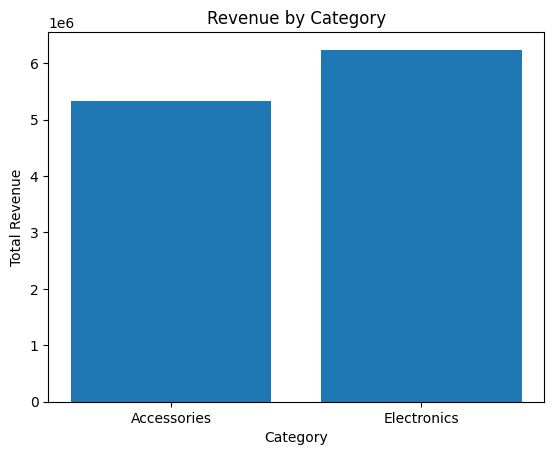

In [21]:
import matplotlib.pyplot as plt

# Group by Category and sum Revenue
category_revenue = df.groupby('Category')['Revenue'].sum()

# Create bar chart
bars = plt.bar(category_revenue.index, category_revenue.values)

# Add labels on bars
# plt.bar_label(bars)

# Titles and labels
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

# plt.xticks(rotation=45)  # rotate labels if categories are long
plt.show()


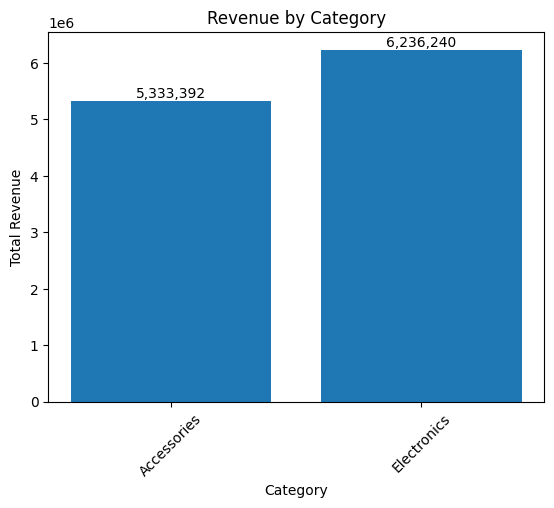

In [35]:
import matplotlib.pyplot as plt

# Group by Category and sum Revenue
category_revenue = df.groupby('Category')['Revenue'].sum()

# Create bar chart
bars = plt.bar(category_revenue.index, category_revenue.values)

# Add numeric labels on top of bars
plt.bar_label(bars, labels=[f"{v:,}" for v in category_revenue.values])
# plt.bar_label(bars)

# Titles and labels
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)  # rotate if category names are long
plt.show()


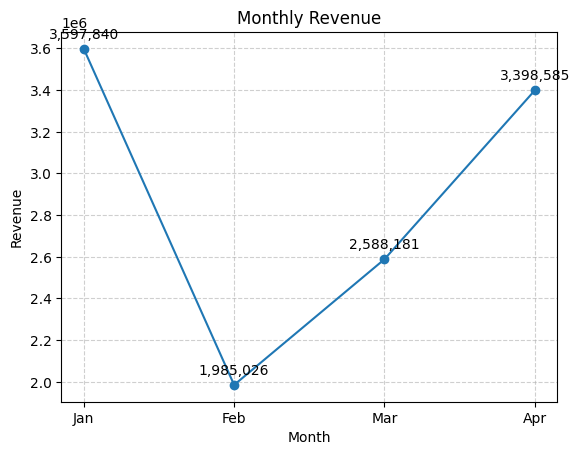

In [37]:
import matplotlib.pyplot as plt

monthly_revenue = df.groupby('Month')['Revenue'].sum()


# Ensure chronological order
order = ["Jan", "Feb", "Mar", "Apr"]
monthly_revenue = monthly_revenue.reindex(order)

# Plot line chart
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

# Add labels
for i, v in enumerate(monthly_revenue.values):
    plt.text(i, v + 50000, f"{v:,}", ha='center')

# Titles and labels
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# https://chatgpt.com/s/t_6a1208fc52c0819189f8cb20385de1c5


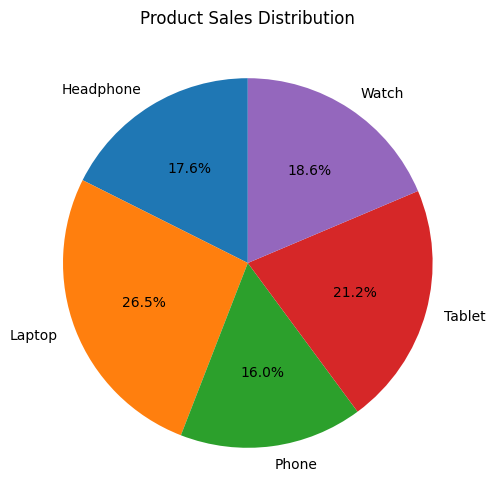

In [24]:
import matplotlib.pyplot as plt

# Group by Product and sum Sales
product_sales = df.groupby('Product')['Revenue'].sum()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(product_sales.values,
        labels=product_sales.index,
        autopct='%1.1f%%',
        startangle=90)

# Title
plt.title('Product Sales Distribution')
plt.show()


In [25]:
df

,OrderID,Product,Category,Quantity,Price,Revenue,Month
0,5001,Laptop,Electronics,6,2846,17076,Mar
1,5002,Phone,Electronics,6,27367,164202,Mar
2,5003,Watch,Accessories,5,31688,158440,Feb
3,5004,Headphone,Accessories,8,34941,279528,Apr
4,5005,Laptop,Accessories,3,45814,137442,Apr
...,...,...,...,...,...,...,...
95,5096,Phone,Electronics,1,5591,5591,Feb
96,5097,Watch,Accessories,1,36270,36270,Mar
97,5098,Watch,Electronics,3,31957,95871,Mar
98,5099,Watch,Electronics,7,9567,66969,Apr
